# pyiron_workflow

[`pyiron_workflow`](https://pyiron-workflow.readthedocs.io/en/latest/) turns plain Python functions into the **nodes** of an explicit, inspectable workflow graph: Python function → workflow node → connected nodes → workflow. Instead of relying on the order in which notebook cells happen to be executed, you declare how data flows between nodes, and `pyiron_workflow` figures out — and can cache — the rest. This notebook rebuilds the same [`workflow.py`](workflow.py) analysis from [`python.ipynb`](python.ipynb) — read CSV → convert load to stress/strain → fit Young's modulus → plot — as a graph.

In [1]:
from concurrent.futures import Future
from pyiron_workflow import Workflow, to_function_node
from workflow import (
    read_csv as _read_csv, 
    calculate_youngs_modulus as _calculate_youngs_modulus, 
    convert_load_to_stress as _convert_load_to_stress, 
    plot as _plot,
)

## Nodes

A function already has most of what a workflow node needs: it takes inputs, performs a defined operation, and produces outputs. `to_function_node` makes that structure explicit by wrapping an existing Python function — unchanged — into a `pyiron_workflow` node: each of the function's arguments becomes a node input, and its return value(s) become node output(s). Nothing about `read_csv`, `convert_load_to_stress`, `calculate_youngs_modulus` or `plot` themselves had to change to make this work — connecting nodes like these into a graph is what turns a collection of functions into a **workflow**.

In [2]:
read_csv = to_function_node("read_csv", _read_csv, "read_csv")
calculate_youngs_modulus = to_function_node("calculate_youngs_modulus", _calculate_youngs_modulus, "calculate_youngs_modulus")
convert_load_to_stress = to_function_node("convert_load_to_stress", _convert_load_to_stress, "convert_load_to_stress")
plot = to_function_node("plot", _plot, "plot")

**What did we gain?**

| Python function | Workflow node |
| --- | --- |
| arguments | explicit input channels |
| return values | explicit output channels |
| a function call | a dependency |
| execution order in code | an explicit dependency graph |
| local execution | managed, cacheable execution |
| an implicit procedure | an inspectable workflow |

None of `read_csv`, `convert_load_to_stress`, `calculate_youngs_modulus` or `plot` had to change — `to_function_node` only adds this extra structure around them.

## Workflow

A `Workflow` is a container for nodes. Assigning `wf.<name> = node(...)` both adds the node to the graph and wires its inputs — either to a plain value or to another node's output, e.g. `wf.result_dict["stress"]`. Execution is lazy: nothing actually runs until `wf.run()` is called, at which point `pyiron_workflow` resolves the dependencies and executes the nodes in the right order.

In [3]:
wf = Workflow("my_workflow")

In [4]:
wf.area = 120
wf.strain_cutoff = 0.2
wf.filename = "./data/dataset_1.csv"
wf.df = read_csv(filename=wf.filename)
wf.result_dict = convert_load_to_stress(df=wf.df, area=wf.area)
wf.youngs_modulus = calculate_youngs_modulus(stress=wf.result_dict["stress"], strain=wf.result_dict["strain"], strain_cutoff=wf.strain_cutoff)
wf.plot = plot(stress=wf.result_dict["stress"], strain=wf.result_dict["strain"], format="-")

{'youngs_modulus__calculate_youngs_modulus': np.float64(175.1800847629701),
 'plot__plot': <Figure size 640x480 with 1 Axes>}

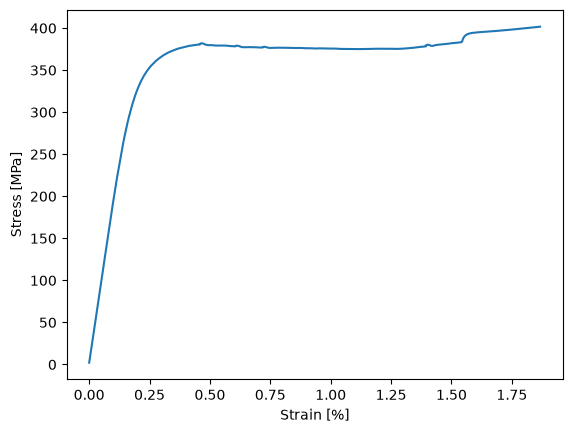

In [5]:
wf.run()

## Workflow Graph

`wf.draw()` renders the same graph visually. Because the graph structure and the Python code are two views of the same underlying object, this is what lets domain scientists and workflow developers collaborate on the same workflow — one thinking in code, the other in the diagram.

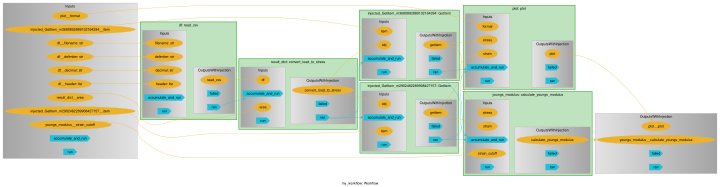

In [6]:
wf.draw(size=(10,10))

**Reproducibility question:** The diagram above shows exactly which inputs feed into `youngs_modulus` — including `strain_cutoff`. Could a collaborator who only sees this diagram, not the code above, tell you which analysis choices went into the result?

## Python Workflow Definition

Saving a workflow is different from saving its result. A result might tell you that `youngs_modulus ≈ 175 GPa`; the workflow additionally records *how* that number was obtained — which functions were called, with which parameters, in which order. The [Python Workflow Definition](https://pythonworkflow.github.io/python-workflow-definition/) is a minimal, engine-agnostic JSON schema for exactly this: nodes reference plain Python functions by their import path, and edges describe how outputs connect to inputs. `write_workflow_json()` exports the `pyiron_workflow` graph above into this format; `load_workflow_json()` reads it back into a fresh `Workflow`. Because the format only relies on plain functions and JSON, the exact same `workflow.json` can also be loaded by a completely different engine — see [`executorlib.ipynb`](executorlib.ipynb).

This connects directly to the FAIR principles for research data:

- **Findable** — the workflow, like the data it produced, can be given an identifier and metadata.
- **Accessible** — a JSON file can be stored, versioned and shared like any other research artefact.
- **Interoperable** — a standardized, engine-agnostic description reduces the dependence of the workflow on any one piece of software.
- **Reusable** — explicit inputs, functions and edges let another researcher understand, rerun and adapt the analysis.

A workflow is not automatically FAIR simply because it was built with `pyiron_workflow` — the JSON file below still needs to be shared, described and versioned alongside the data it operates on. But it is what makes the *procedure*, not only the *result*, something that can be findable, accessible, interoperable and reused.

### References

- Janssen, J., George, J., Geiger, J., Bercx, M., Wang, X., Ertural, C., Schaarschmidt, J., Ganose, A. M., Pizzi, G., Hickel, T., & Neugebauer, J. (2025). A Python workflow definition for computational materials design. Digital Discovery. https://doi.org/10.1039/d5dd00231a

In [7]:
from python_workflow_definition.pyiron_workflow import write_workflow_json

In [8]:
wf = Workflow("my_workflow")
wf.area = 120
wf.strain_cutoff = 0.2
wf.filename = "./data/dataset_1.csv"
wf.df = read_csv(filename=wf.filename)
wf.result_dict = convert_load_to_stress(df=wf.df, area=wf.area)
wf.youngs_modulus = calculate_youngs_modulus(stress=wf.result_dict["stress"], strain=wf.result_dict["strain"], strain_cutoff=wf.strain_cutoff)

In [9]:
write_workflow_json(graph_as_dict=wf.graph_as_dict, file_name="workflow.json")

In [10]:
!cat workflow.json

{
  "version": "0.1.0",
  "nodes": [
    {
      "id": 0,
      "type": "function",
      "value": "workflow.read_csv"
    },
    {
      "id": 1,
      "type": "function",
      "value": "workflow.convert_load_to_stress"
    },
    {
      "id": 2,
      "type": "function",
      "value": "workflow.calculate_youngs_modulus"
    },
    {
      "id": 3,
      "type": "input",
      "name": "filename",
      "value": "./data/dataset_1.csv"
    },
    {
      "id": 4,
      "type": "input",
      "name": "header",
      "value": [
        0,
        1
      ]
    },
    {
      "id": 5,
      "type": "input",
      "name": "decimal",
      "value": ","
    },
    {
      "id": 6,
      "type": "input",
      "name": "delimiter",
      "value": ";"
    },
    {
      "id": 7,
      "type": "input",
      "name": "area",
      "value": 120
    },
    {
      "id": 8,
      "type": "input",
      "name": "strain_cutoff",
      "value": 0.2
    },
    {
      "id": 9,
      "type": "output",


In [11]:
from python_workflow_definition.pyiron_workflow import load_workflow_json

In [12]:
wf = load_workflow_json(file_name="workflow.json")

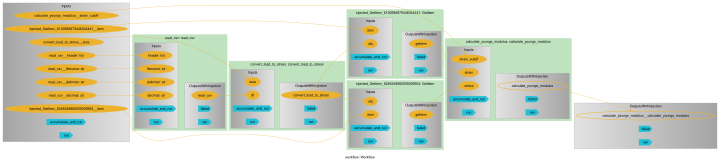

In [13]:
wf.draw(size=(10,10))

In [14]:
wf.run()

{'calculate_youngs_modulus__calculate_youngs_modulus': np.float64(175.1800847629701)}

### From one analysis to a parameter study

<div class="admonition note" name="html-admonition" style="background: #FFEDD1; padding: 10px">
<p class="title"><b>Task</b></p>

Re-run <code>wf</code> for a few different values of <code>strain_cutoff</code> (e.g. <code>0.1</code>, <code>0.2</code>, <code>0.3</code>) by setting <code>wf.strain_cutoff = ...</code> and calling <code>wf.run()</code> again, collecting the resulting <code>youngs_modulus</code> each time. Plot the Young's modulus against <code>strain_cutoff</code>.

How sensitive is the result to this analysis choice? Note that this is still a single workflow definition, evaluated several times with different inputs — a parameter study is a natural consequence of having an explicit, reusable workflow, not something that requires a different tool.
</div>

## Next steps

Continue with [`executorlib.ipynb`](executorlib.ipynb) to execute this same workflow — including the `workflow.json` exported above — with a lightweight, HPC-ready executor instead of a graph engine, or see [`pyironflow.ipynb`](pyironflow.ipynb) to build and run this same `wf` graph through a graphical, drag-and-drop interface instead of code.